In [123]:
%pylab inline
#code units
Mstar = 1
R0 = 1
G = 1
R_MU = 1

#cgs units
kB_CGS = 1.38064852e-16      # erg / K
mH_CGS = 2.4 * 1.67262192369e-24 # g (μ = 2.4)
Mstar_CGS = 1.9891e33            # g
G_CGS = 6.674e-8
AU_CM = 1.49597871e13
R0_CGS = 40.0 * AU_CM
R_MU_CGS = 36149835.0
gamma = 1.4

# ERGS macro for scale-free fondam (G=MSTAR=R0=1): one code energy unit [erg]
ergs_code = 1/((R0/R0_CGS) / ((G/G_CGS) * (Mstar/Mstar_CGS)**2))
Kelvin_code = ((G*Mstar/R0/R_MU)/(G_CGS*Mstar_CGS/R0_CGS/R_MU_CGS))

# k_B in code units ergs per kelvin
kB_code = kB_CGS * ergs_code/ Kelvin_code

# One particle mass in code units if 1 code mass = one stellar mass
mH_code = mH_CGS * (Mstar/ Mstar_CGS)


print(kB_code/ mH_code)


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib
0.9514101616899105


In [166]:
rmin = loadtxt("../../outputs/vsi_128_iso/domain_y.dat")[3:-3]
tmin = loadtxt("../../outputs/vsi_128_iso/domain_z.dat")[3:-3]

rmed = 0.5 * (rmin[1:] + rmin[:-1])
tmed = 0.5 * (tmin[1:] + tmin[:-1])

R, T = meshgrid(rmed, tmed)

nz = 128
ny = 128


0.0


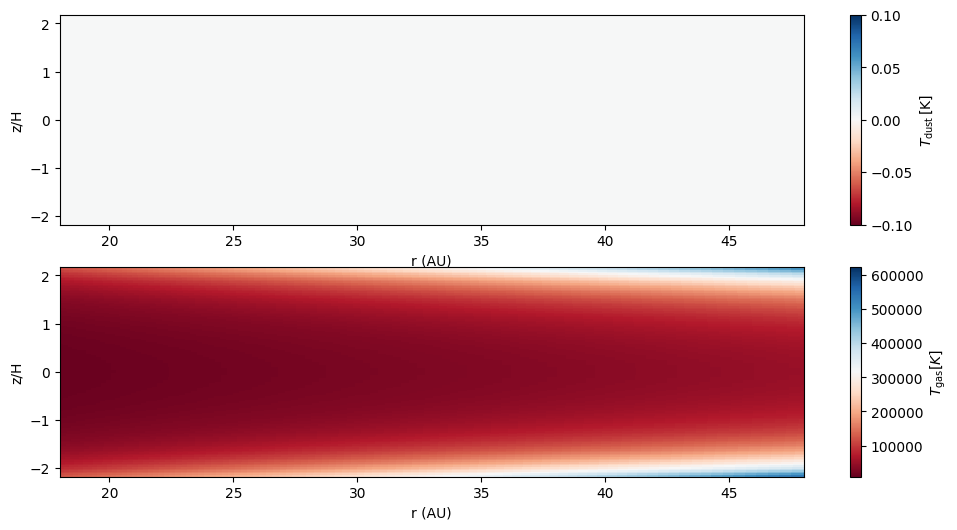

In [200]:
n =6

vthetan_th = fromfile("../../outputs/vsi_128_iso/gasvz{:d}.dat".format(n)).reshape(nz,ny)
rhodn_th = fromfile("../../outputs/vsi_128_iso/dust1dens{:d}.dat".format(n)).reshape(nz,ny)
edn_th = fromfile("../../outputs/vsi_128_iso/dust1energy{:d}.dat".format(n)).reshape(nz,ny)
egn_th = fromfile("../../outputs/vsi_128_iso/gasenergy{:d}.dat".format(n)).reshape(nz,ny)
rhogn_th = fromfile("../../outputs/vsi_128_iso/gasdens{:d}.dat".format(n)).reshape(nz,ny)

# tcol = fromfile("../../outputs/vsi_128_iso/Tcol{:d}.dat".format(n)).reshape(nz,ny)


cg = gamma * R_MU /(gamma -1)
cd = 0.088* cg

Tdust = edn_th / rhodn_th / Kelvin_code / cd

Tgas = egn_th / rhogn_th / Kelvin_code / cg

H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
print(np.mean(tcol))
# surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, Tdust, cmap='RdBu')

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$T_{\rm dust}\, [\rm K]$')

# fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')


ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, Tgas, cmap='RdBu')
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$T_{\rm gas} [K]$')
show()

In [217]:
n =32

vthetan_th = fromfile("../../outputs/vsi_128_iso/gasvz{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d= fromfile("../../outputs//vsi_128_iso/dust1vz{:d}.dat".format(n)).reshape(nz,ny)
# tcol= fromfile("../../outputs//vsi_128_iso/Tcol{:d}.dat".format(n)).reshape(nz,ny)


cg = R_MU /(gamma -1)
cd = 0.088* cg

Tdust = edn_th / rhodn_th / Kelvin_code / cd

H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
print(1/np.mean(tcol))
# surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_th, cmap='RdBu', vmin=-0.01,vmax=0.01)

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$T\, [\rm K]$')

# fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')

ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_d, cmap='RdBu', vmin=-0.01,vmax=0.01)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

FileNotFoundError: [Errno 2] No such file or directory: '../../outputs/vsi_128_iso/gasvz32.dat'

-49.08462490204956


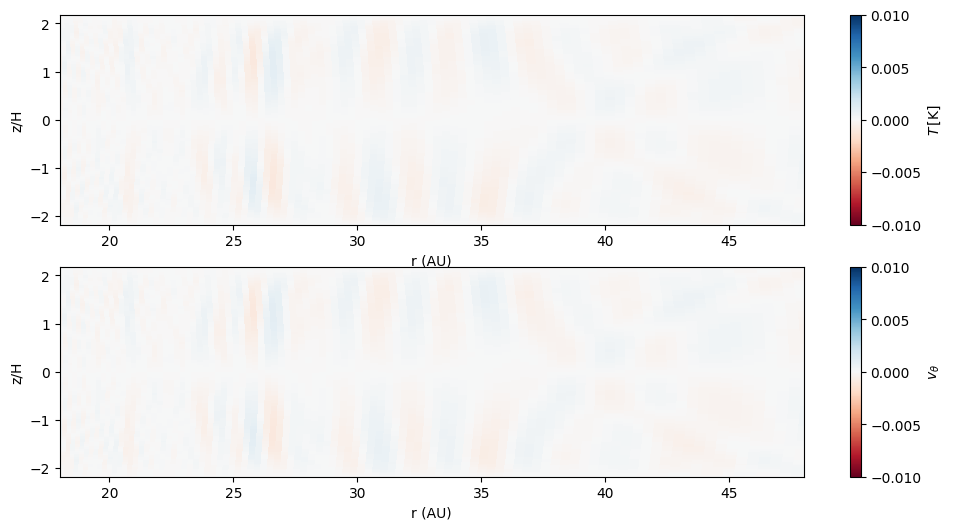

In [ ]:
n =100

vthetan_th = fromfile("../../outputs/vsi_128_adi/gasvz{:d}.dat".format(n)).reshape(nz,ny)
vthetan_d= fromfile("../../outputs//vsi_128_adi/dust1vz{:d}.dat".format(n)).reshape(nz,ny)
tcol= fromfile("../../outputs//vsi_128_adi/Tcol{:d}.dat".format(n)).reshape(nz,ny)


cg = R_MU /(gamma -1)
cd = 0.088* cg

Tdust = edn_th / rhodn_th / Kelvin_code / cd

H0 = 0.06
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
print(1/np.mean(tcol))
# surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(1/tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm(vmin = 1e-2, vmax = 1e2))
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_th, cmap='RdBu', vmin=-0.01,vmax=0.01)

ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$T\, [\rm K]$')

# fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')


ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_d, cmap='RdBu', vmin=-0.01,vmax=0.01)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

/var/folders/_0/vjjwsf2n78qf97zssfnywywr0000gn/T/ipykernel_3653/3269527207.py:21: UserWarning: Adding colorbar to a different Figure <Figure size 1200x600 with 4 Axes> than <Figure size 1200x600 with 4 Axes> which fig.colorbar is called on.
  fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')


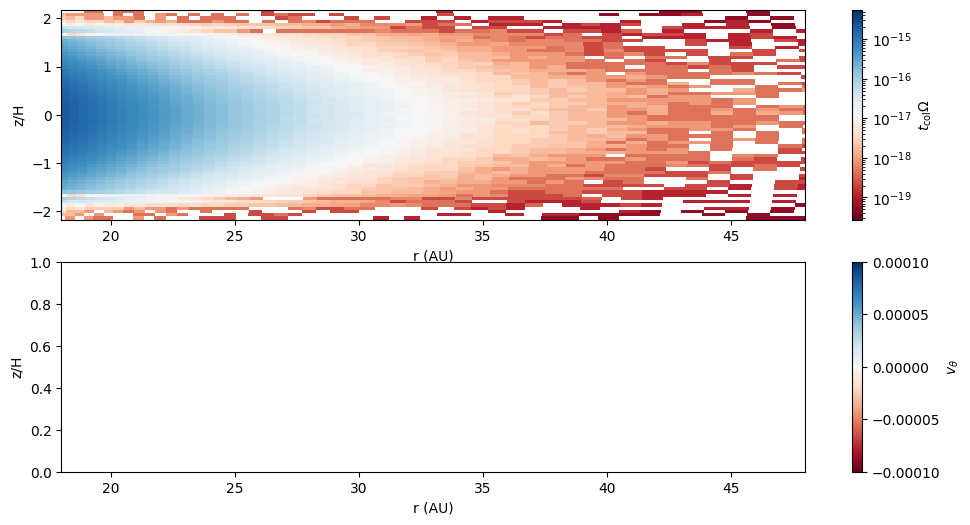

In [49]:
n = 50

tcol = fromfile("../../outputs/vsi_lin/Tcol{:d}.dat".format(n)).reshape(nz,ny)
H0 = 0.06

fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
surf1 = ax1.pcolormesh(30*R*sin(T),cos(T)/H0, np.abs(tcol), cmap='RdBu', norm =matplotlib.colors.LogNorm())
ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6*30, 1.6*30)
fig.colorbar(surf1, ax=ax1, label=r'$t_{\rm col}  \Omega$')


ax2 = fig.add_subplot(212)
# surf2 = ax2.pcolormesh(30*R*sin(T),cos(T)/H0, vthetan_th, cmap='RdBu', vmin=-0.0001,vmax=0.0001)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(30*0.6, 30*1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

/var/folders/g7/k0wvlblx2w945dl7w90fr6qh0000gn/T/ipykernel_18574/2697910196.py:4: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  surf1 = ax1.pcolormesh(R*sin(T),cos(T)/H0, log10(rhod1n_th), cmap='Spectral_r', vmin=-6)
/var/folders/g7/k0wvlblx2w945dl7w90fr6qh0000gn/T/ipykernel_18574/2697910196.py:12: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  surf2 = ax2.pcolormesh(R*sin(T),cos(T)/H0, log10(rhod2n_th), cmap='Spectral_r',vmin=-6)


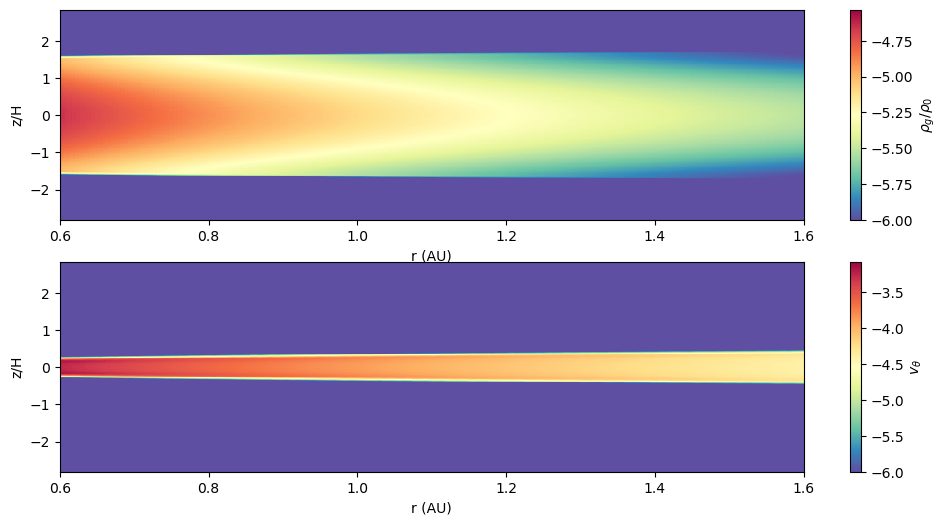

In [242]:
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
surf1 = ax1.pcolormesh(R*sin(T),cos(T)/H0, log10(rhod1n_th), cmap='Spectral_r', vmin=-6)
ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6, 1.6)
fig.colorbar(surf1, ax=ax1, label=r'$\rho_g/\rho_0$')


ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(R*sin(T),cos(T)/H0, log10(rhod2n_th), cmap='Spectral_r',vmin=-6)
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(0.6, 1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()

/var/folders/g7/k0wvlblx2w945dl7w90fr6qh0000gn/T/ipykernel_18574/1605677921.py:4: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  surf1 = ax1.pcolormesh(R*sin(T),cos(T)/H0, log10(egn), cmap='Spectral_r')
/var/folders/g7/k0wvlblx2w945dl7w90fr6qh0000gn/T/ipykernel_18574/1605677921.py:12: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  surf2 = ax2.pcolormesh(R*sin(T),cos(T)/H0, log10(egn_th/rhogn_th/0.4), cmap='Spectral_r')


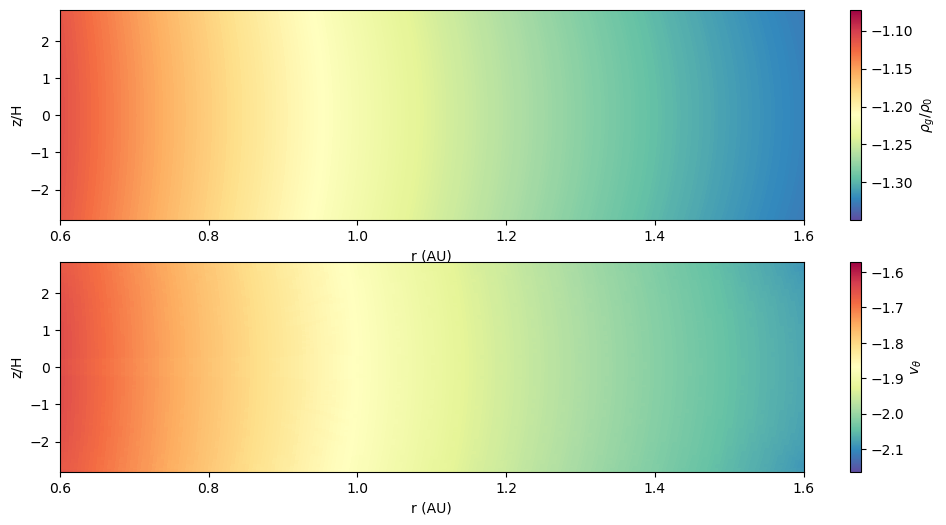

In [243]:
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(211)
surf1 = ax1.pcolormesh(R*sin(T),cos(T)/H0, log10(egn), cmap='Spectral_r')
ax1.set_xlabel('r (AU)')
ax1.set_ylabel('z/H')
ax1.set_xlim(0.6, 1.6)
fig.colorbar(surf1, ax=ax1, label=r'$\rho_g/\rho_0$')


ax2 = fig.add_subplot(212)
surf2 = ax2.pcolormesh(R*sin(T),cos(T)/H0, log10(egn_th/rhogn_th/0.4), cmap='Spectral_r')
ax2.set_xlabel('r (AU)')
ax2.set_ylabel('z/H')
ax2.set_xlim(0.6, 1.6)
fig.colorbar(surf2, ax=ax2, label=r'$v_\theta$')
show()